# Clasificador Multimodal Multietiqueta con COCO

Este notebook entrena un clasificador que combina **imagen + caption** para predecir categorías de objetos de COCO. Los encoders de CLIP permanecen congelados y se entrena una cabeza neuronal sobre sus embeddings concatenados.

Una imagen puede contener varias categorías simultáneamente, por lo que el problema es de **clasificación multietiqueta** y utiliza `BCEWithLogitsLoss`.

## Archivos requeridos

Descarga desde [COCO](https://cocodataset.org/#download):

- 2017 Train images
- 2017 Val images
- 2017 Train/Val annotations

Descomprime con esta estructura:

```text
Data/coco/
├── train2017/
├── val2017/
└── annotations/
    ├── instances_train2017.json
    ├── instances_val2017.json
    ├── captions_train2017.json
    └── captions_val2017.json
```


In [1]:
# ============================================================================
# 1. DEPENDENCIAS Y REPRODUCIBILIDAD
# ============================================================================

import importlib.util
import subprocess
import sys

DEPENDENCIES = {
    "torch": "torch",
    "transformers": "transformers",
    "PIL": "pillow",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "tqdm": "tqdm",
    "gradio": "gradio",
}
missing = [package for module, package in DEPENDENCIES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import hashlib
import json
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [2]:
# ============================================================================
# 2. CONFIGURACIÓN
# ============================================================================

PROJECT_DIR = Path.cwd()
COCO_DIR = PROJECT_DIR / "Data" / "coco"
ANNOTATIONS_DIR = COCO_DIR / "annotations"
TRAIN_IMAGES_DIR = COCO_DIR / "train2017"
VAL_IMAGES_DIR = COCO_DIR / "val2017"

# Categorías frecuentes para mantener el proyecto manejable.
TARGET_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "bus", "train",
    "truck", "boat", "bird", "cat", "dog", "horse",
]

MAX_TRAIN_SAMPLES = 20_000  # Segundo experimento: mayor cobertura de COCO.
MAX_VAL_SAMPLES = 5_000
EMBEDDING_BATCH_SIZE = 32
TRAIN_BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
USE_CACHE = True

device = torch.device("cpu")
print(f"Device: {device}")
print(f"Directorio COCO: {COCO_DIR}")


Device: cpu
Directorio COCO: d:\ProcLN\Procesamiento_Natural_del_Lenguaje_2026\Modulo III\ProyectoFinalUJ\Data\coco


In [3]:
# ============================================================================
# 3. CARGA DE ANOTACIONES COCO
# ============================================================================

def load_json(path):
    if not path.is_file():
        raise FileNotFoundError(
            f"No se encontró {path}. Revisa la estructura indicada al inicio."
        )
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def build_records(split, images_dir, max_samples=None, seed=SEED):
    instances = load_json(ANNOTATIONS_DIR / f"instances_{split}2017.json")
    captions = load_json(ANNOTATIONS_DIR / f"captions_{split}2017.json")

    category_name_to_id = {category["name"]: category["id"]
                           for category in instances["categories"]}
    unknown = sorted(set(TARGET_CLASSES) - set(category_name_to_id))
    if unknown:
        raise ValueError(f"Categorías inexistentes en COCO: {unknown}")

    selected_ids = {category_name_to_id[name]: index
                    for index, name in enumerate(TARGET_CLASSES)}
    labels_by_image = defaultdict(set)
    for annotation in instances["annotations"]:
        category_id = annotation["category_id"]
        if category_id in selected_ids:
            labels_by_image[annotation["image_id"]].add(selected_ids[category_id])

    captions_by_image = defaultdict(list)
    for annotation in captions["annotations"]:
        captions_by_image[annotation["image_id"]].append(annotation["caption"])

    images_by_id = {image["id"]: image for image in instances["images"]}
    candidate_ids = [
        image_id for image_id in labels_by_image
        if image_id in captions_by_image
        and (images_dir / images_by_id[image_id]["file_name"]).is_file()
    ]

    generator = np.random.default_rng(seed)
    generator.shuffle(candidate_ids)
    if max_samples is not None:
        candidate_ids = candidate_ids[:max_samples]

    records = []
    for image_id in candidate_ids:
        label = np.zeros(len(TARGET_CLASSES), dtype=np.float32)
        label[list(labels_by_image[image_id])] = 1.0
        records.append({
            "image_id": image_id,
            "image_path": images_dir / images_by_id[image_id]["file_name"],
            "caption": captions_by_image[image_id][0],
            "labels": label,
        })
    return records


train_records = build_records("train", TRAIN_IMAGES_DIR, MAX_TRAIN_SAMPLES)
val_records = build_records("val", VAL_IMAGES_DIR, MAX_VAL_SAMPLES, SEED + 1)

if not train_records or not val_records:
    raise RuntimeError("No se encontraron ejemplos válidos de entrenamiento/validación.")

print(f"Entrenamiento: {len(train_records):,} imágenes")
print(f"Validación: {len(val_records):,} imágenes")


Entrenamiento: 20,000 imágenes
Validación: 3,412 imágenes


,clase,train,val
0,person,15968,2693
1,bicycle,793,149
2,car,2984,535
3,motorcycle,831,159
4,bus,957,189
5,train,886,157
6,truck,1509,250
7,boat,752,121
8,bird,846,125
9,cat,1005,184


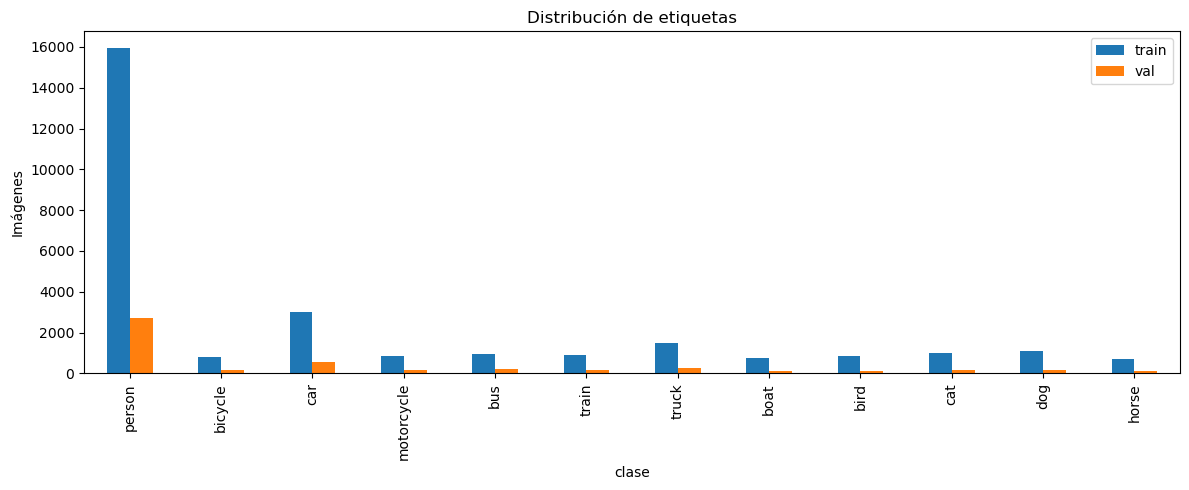

In [4]:
# ============================================================================
# 4. DISTRIBUCIÓN DE ETIQUETAS
# ============================================================================

train_label_matrix = np.vstack([record["labels"] for record in train_records])
val_label_matrix = np.vstack([record["labels"] for record in val_records])

distribution = pd.DataFrame({
    "clase": TARGET_CLASSES,
    "train": train_label_matrix.sum(axis=0).astype(int),
    "val": val_label_matrix.sum(axis=0).astype(int),
})
display(distribution)

distribution.set_index("clase")[["train", "val"]].plot(
    kind="bar", figsize=(12, 5), title="Distribución de etiquetas"
)
plt.ylabel("Imágenes")
plt.tight_layout()
plt.show()


In [5]:
# ============================================================================
# 5. EMBEDDINGS MULTIMODALES CON CLIP CONGELADO
# ============================================================================

MODEL_NAME = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(device).eval()
for parameter in clip_model.parameters():
    parameter.requires_grad = False


@torch.inference_mode()
def embed_batch(images, texts):
    image_inputs = processor(images=images, return_tensors="pt")
    pixel_values = image_inputs["pixel_values"].to(device)
    image_outputs = clip_model.vision_model(pixel_values=pixel_values)
    image_features = clip_model.visual_projection(image_outputs.pooler_output)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    text_inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)
    input_ids = text_inputs["input_ids"].to(device)
    attention_mask = text_inputs.get("attention_mask")
    if attention_mask is not None:
        attention_mask = attention_mask.to(device)
    text_outputs = clip_model.text_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )
    text_features = clip_model.text_projection(text_outputs.pooler_output)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return torch.cat([image_features, text_features], dim=1).cpu().numpy()


def extract_embeddings(records, batch_size=EMBEDDING_BATCH_SIZE):
    feature_batches = []
    labels = np.vstack([record["labels"] for record in records])

    for start in tqdm(range(0, len(records), batch_size), desc="Embeddings"):
        batch = records[start:start + batch_size]
        images = []
        try:
            for record in batch:
                with Image.open(record["image_path"]) as image:
                    images.append(image.convert("RGB").copy())
            texts = [record["caption"] for record in batch]
            feature_batches.append(embed_batch(images, texts))
        finally:
            for image in images:
                image.close()

    return np.vstack(feature_batches).astype(np.float32), labels.astype(np.float32)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [6]:
# ============================================================================
# 6. GENERAR O CARGAR LA CACHÉ DE EMBEDDINGS
# ============================================================================

CACHE_DIR = COCO_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
class_signature = hashlib.sha1("|".join(TARGET_CLASSES).encode()).hexdigest()[:8]


def cached_embeddings(records, split):
    cache_path = CACHE_DIR / f"{split}_{len(records)}_{class_signature}.npz"
    if USE_CACHE and cache_path.is_file():
        cached = np.load(cache_path)
        print(f"✓ Caché cargada: {cache_path.name}")
        return cached["features"], cached["labels"]

    features, labels = extract_embeddings(records)
    if USE_CACHE:
        np.savez_compressed(cache_path, features=features, labels=labels)
        print(f"✓ Caché guardada: {cache_path.name}")
    return features, labels


X_train, y_train = cached_embeddings(train_records, "train")
X_val, y_val = cached_embeddings(val_records, "val")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)


Embeddings:   0%|          | 0/625 [00:00<?, ?it/s]

✓ Caché guardada: train_20000_cd464378.npz


Embeddings:   0%|          | 0/107 [00:00<?, ?it/s]

✓ Caché guardada: val_3412_cd464378.npz
Train: (20000, 1024) (20000, 12)
Val: (3412, 1024) (3412, 12)


In [7]:
# ============================================================================
# 7. CLASIFICADOR MULTIETIQUETA Y PARTICIONES DE EVALUACIÓN
# ============================================================================

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))

# val2017 se divide en calibración y prueba. Los umbrales se aprenden solamente
# con calibración; las métricas finales se calculan sobre prueba.
split_generator = np.random.default_rng(SEED)
validation_indices = split_generator.permutation(len(X_val))
split_point = len(validation_indices) // 2
calibration_indices = validation_indices[:split_point]
test_indices = validation_indices[split_point:]

X_calibration, y_calibration = X_val[calibration_indices], y_val[calibration_indices]
X_test, y_test = X_val[test_indices], y_val[test_indices]
test_records = [val_records[index] for index in test_indices]

calibration_dataset = TensorDataset(
    torch.from_numpy(X_calibration), torch.from_numpy(y_calibration)
)
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE,
                          shuffle=True, num_workers=0)
val_loader = DataLoader(calibration_dataset, batch_size=TRAIN_BATCH_SIZE,
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=TRAIN_BATCH_SIZE,
                         shuffle=False, num_workers=0)


class MultimodalClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(512, num_classes),
        )

    def forward(self, features):
        return self.network(features)


classifier = MultimodalClassifier(X_train.shape[1], len(TARGET_CLASSES)).to(device)

positive_count = torch.from_numpy(y_train.sum(axis=0)).float()
negative_count = len(y_train) - positive_count
positive_weight = (negative_count / positive_count.clamp_min(1)).clamp(max=20).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=LEARNING_RATE,
                              weight_decay=1e-4)

print(f"Train: {len(train_dataset):,}")
print(f"Calibración: {len(calibration_dataset):,}")
print(f"Prueba: {len(test_dataset):,}")
print(classifier)


Train: 20,000
Calibración: 1,706
Prueba: 1,706
MultimodalClassifier(
  (network): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=12, bias=True)
  )
)


In [9]:
# ============================================================================
# 8. ENTRENAMIENTO
# ============================================================================

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None

for epoch in range(EPOCHS):
    classifier.train()
    train_loss = 0.0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(classifier(features), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(features)

    classifier.eval()
    val_loss = 0.0
    with torch.inference_mode():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            loss = criterion(classifier(features), labels)
            val_loss += loss.item() * len(features)

    train_loss /= len(train_dataset)
    val_loss /= len(calibration_dataset)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {name: value.detach().cpu().clone()
                      for name, value in classifier.state_dict().items()}

    print(f"Epoch {epoch + 1:02d}/{EPOCHS} | "
          f"train={train_loss:.4f} | val={val_loss:.4f}")

classifier.load_state_dict(best_state)
torch.save({
    "state_dict": classifier.state_dict(),
    "classes": TARGET_CLASSES,
    "model_name": MODEL_NAME,
}, PROJECT_DIR / "clasificador_multimodal_coco.pt")
print("✓ Mejor modelo guardado")


Epoch 01/10 | train=0.3664 | val=0.3835
Epoch 02/10 | train=0.3274 | val=0.3676
Epoch 03/10 | train=0.3026 | val=0.3642
Epoch 04/10 | train=0.2853 | val=0.3588
Epoch 05/10 | train=0.2715 | val=0.3598
Epoch 06/10 | train=0.2585 | val=0.3557
Epoch 07/10 | train=0.2493 | val=0.3555
Epoch 08/10 | train=0.2392 | val=0.3635
Epoch 09/10 | train=0.2306 | val=0.3667
Epoch 10/10 | train=0.2247 | val=0.3676
✓ Mejor modelo guardado


,umbral_0.50,umbrales_calibrados
F1 micro,0.746726,0.864390
F1 macro,0.686480,0.809780
Precision micro,0.645132,0.844653
Recall micro,0.886299,0.885072


,umbral,precision,recall,f1-score,support
person,0.200,0.956753,0.941045,0.948834,1340.0
bicycle,0.800,0.535088,0.772152,0.632124,79.0
car,0.800,0.694352,0.746429,0.719449,280.0
motorcycle,0.800,0.835294,0.797753,0.816092,89.0
bus,0.800,0.704000,0.888889,0.785714,99.0
train,0.750,0.909091,0.909091,0.909091,77.0
truck,0.800,0.509677,0.642276,0.568345,123.0
boat,0.800,0.746269,0.862069,0.800000,58.0
bird,0.800,0.783784,0.852941,0.816901,68.0
cat,0.775,0.954545,0.954545,0.954545,88.0


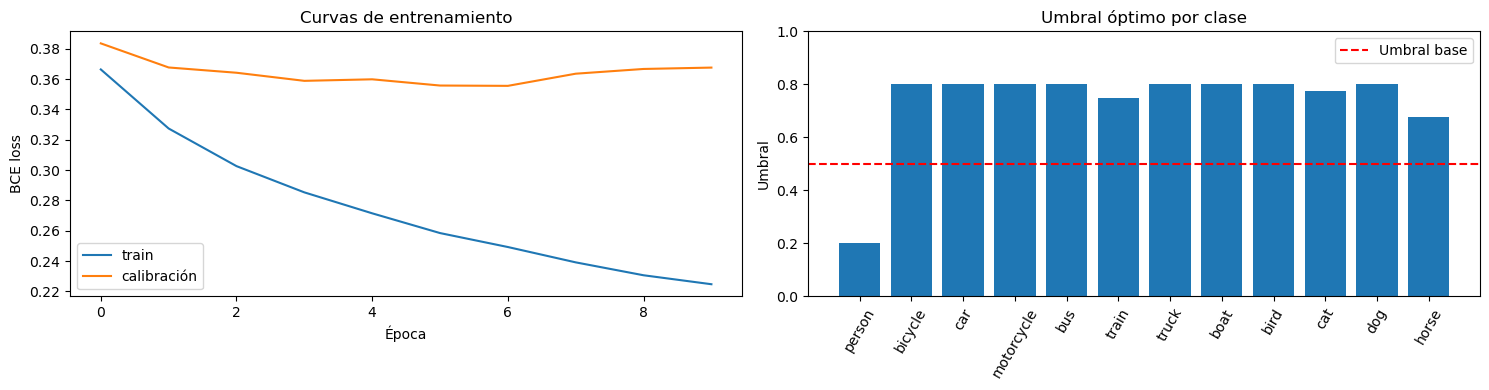

In [10]:
# ============================================================================
# 9. CALIBRACIÓN DE UMBRALES Y EVALUACIÓN SOBRE PRUEBA
# ============================================================================

def predict_probabilities(loader):
    batches = []
    classifier.eval()
    with torch.inference_mode():
        for features, _ in loader:
            logits = classifier(features.to(device))
            batches.append(torch.sigmoid(logits).cpu().numpy())
    return np.vstack(batches)


calibration_probabilities = predict_probabilities(val_loader)
probabilities = predict_probabilities(test_loader)

# Buscar el umbral que maximiza F1 para cada clase usando solo calibración.
threshold_candidates = np.arange(0.20, 0.81, 0.025)
optimal_thresholds = []
for class_index in range(len(TARGET_CLASSES)):
    scores = [
        f1_score(
            y_calibration[:, class_index],
            calibration_probabilities[:, class_index] >= threshold,
            zero_division=0,
        )
        for threshold in threshold_candidates
    ]
    optimal_thresholds.append(threshold_candidates[int(np.argmax(scores))])
optimal_thresholds = np.asarray(optimal_thresholds)

baseline_predictions = (probabilities >= 0.50).astype(np.int32)
predictions = (probabilities >= optimal_thresholds).astype(np.int32)


def metric_summary(targets, predicted):
    return {
        "F1 micro": f1_score(targets, predicted, average="micro", zero_division=0),
        "F1 macro": f1_score(targets, predicted, average="macro", zero_division=0),
        "Precision micro": precision_score(
            targets, predicted, average="micro", zero_division=0
        ),
        "Recall micro": recall_score(
            targets, predicted, average="micro", zero_division=0
        ),
    }


comparison = pd.DataFrame({
    "umbral_0.50": metric_summary(y_test, baseline_predictions),
    "umbrales_calibrados": metric_summary(y_test, predictions),
})
display(comparison)

report = classification_report(
    y_test, predictions, target_names=TARGET_CLASSES,
    output_dict=True, zero_division=0,
)
per_class = pd.DataFrame(report).T.loc[
    TARGET_CLASSES, ["precision", "recall", "f1-score", "support"]
]
per_class.insert(0, "umbral", optimal_thresholds)
display(per_class)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="calibración")
axes[0].set(xlabel="Época", ylabel="BCE loss", title="Curvas de entrenamiento")
axes[0].legend()

axes[1].bar(TARGET_CLASSES, optimal_thresholds)
axes[1].axhline(0.50, color="red", linestyle="--", label="Umbral base")
axes[1].set(title="Umbral óptimo por clase", ylabel="Umbral", ylim=(0, 1))
axes[1].tick_params(axis="x", rotation=60)
axes[1].legend()
plt.tight_layout()
plt.show()


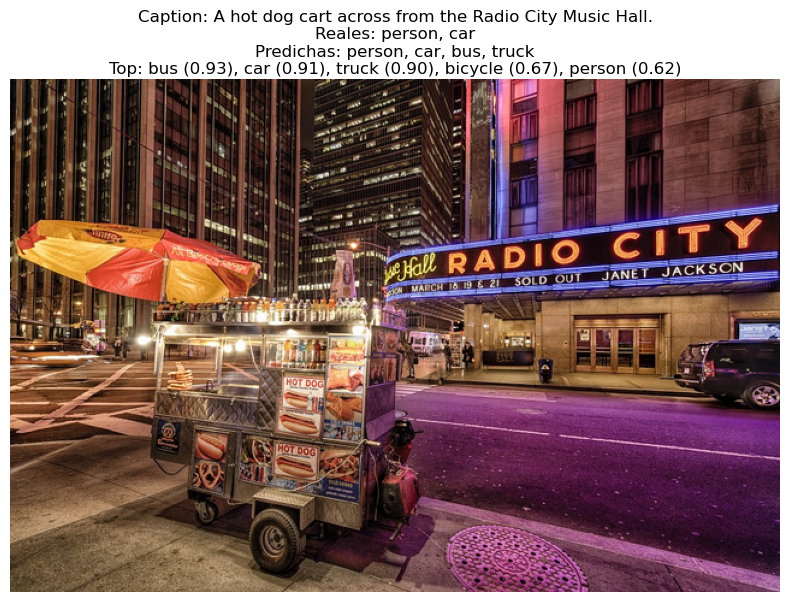

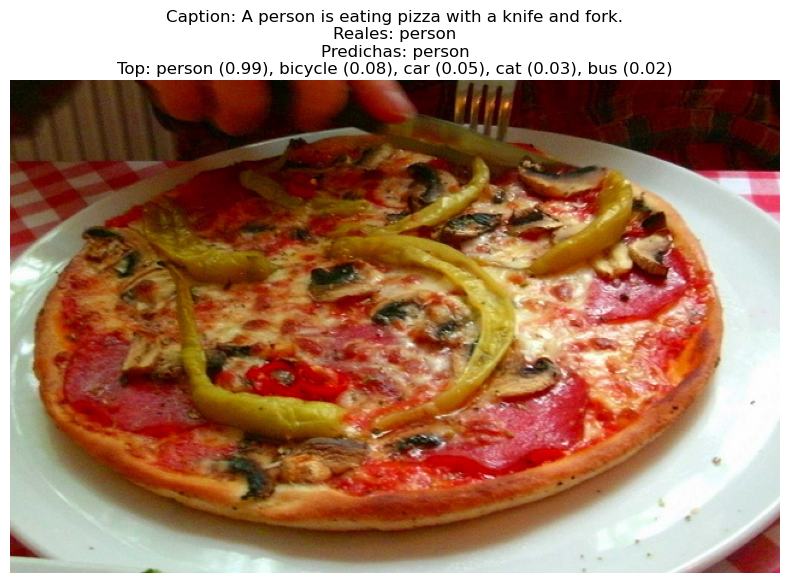

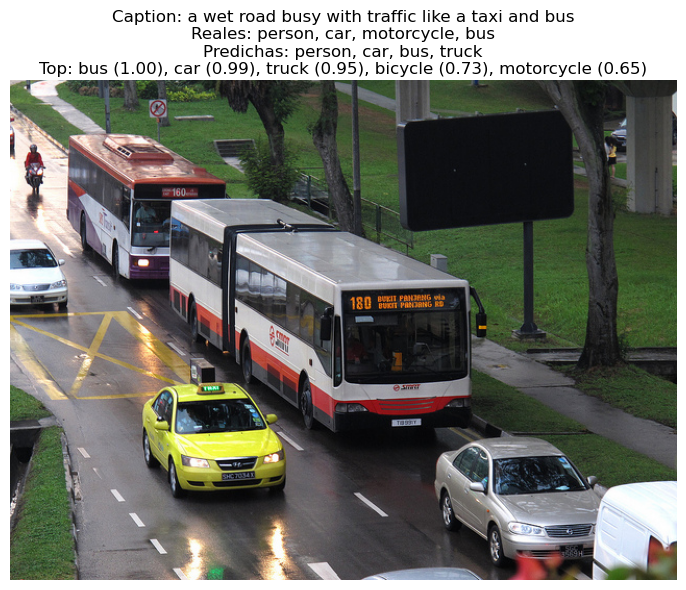

In [11]:
# ============================================================================
# 10. INSPECCIÓN DE PREDICCIONES SOBRE EL CONJUNTO DE PRUEBA
# ============================================================================

def show_prediction(index):
    record = test_records[index]
    true_names = [name for name, value in zip(TARGET_CLASSES, y_test[index]) if value]
    predicted_names = [
        name for name, score, threshold in zip(
            TARGET_CLASSES, probabilities[index], optimal_thresholds
        )
        if score >= threshold
    ]
    top_scores = sorted(
        zip(TARGET_CLASSES, probabilities[index]),
        key=lambda item: item[1], reverse=True,
    )[:5]

    with Image.open(record["image_path"]) as source_image:
        image = source_image.convert("RGB").copy()
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Caption: {record['caption']}\n"
        f"Reales: {', '.join(true_names)}\n"
        f"Predichas: {', '.join(predicted_names) or 'ninguna'}\n"
        f"Top: " + ", ".join(f"{name} ({score:.2f})" for name, score in top_scores),
        wrap=True,
    )
    plt.tight_layout()
    plt.show()


sample_size = min(3, len(test_records))
for index in np.random.default_rng(SEED).choice(
    len(test_records), size=sample_size, replace=False
):
    show_prediction(int(index))


In [12]:
# ============================================================================
# 11. DEMO GRADIO
# ============================================================================

import gradio as gr


def predict_multimodal(image, caption, threshold=0.5):
    if image is None:
        return {}
    image = Image.fromarray(image).convert("RGB") if isinstance(image, np.ndarray) else image.convert("RGB")
    text = caption.strip() if caption and caption.strip() else "a photo"
    features = embed_batch([image], [text])
    tensor = torch.from_numpy(features).to(device)
    with torch.inference_mode():
        scores = torch.sigmoid(classifier(tensor))[0].cpu().numpy()

    result = {name: float(score) for name, score in zip(TARGET_CLASSES, scores)
              if score >= threshold}
    if not result:
        top = np.argsort(scores)[::-1][:3]
        result = {TARGET_CLASSES[index]: float(scores[index]) for index in top}
    return result


demo = gr.Interface(
    fn=predict_multimodal,
    inputs=[
        gr.Image(type="pil", label="Imagen"),
        gr.Textbox(label="Caption opcional", placeholder="A dog running near a person"),
        gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Umbral"),
    ],
    outputs=gr.Label(num_top_classes=len(TARGET_CLASSES), label="Categorías"),
    title="Clasificador multimodal COCO",
    description="Combina embeddings CLIP de imagen y texto.",
)

print("✓ Demo creada. Ejecuta demo.launch() en otra celda para abrirla.")


✓ Demo creada. Ejecuta demo.launch() en otra celda para abrirla.


In [13]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Using existing dataset file at: .gradio\flagged\dataset1.csv


## Notas metodológicas

- Las etiquetas provienen de las anotaciones de instancias de COCO, no de palabras clave extraídas de los captions.
- El modelo es multietiqueta: utiliza una salida sigmoide independiente para cada categoría.
- CLIP se usa como extractor congelado; solamente se entrena la cabeza clasificadora.
- Para un resultado final, aumenta las muestras, revisa el balance de clases y ajusta el umbral con validación.
- Las métricas deben reportarse sobre `val2017`, que nunca participa en el entrenamiento.
